<a href="https://colab.research.google.com/github/divyamjariwal/Deep-Learning-Lab/blob/main/DL_LAB5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

EXPERIMENT 5

Installing Library

In [9]:
!pip -q install torch nltk matplotlib pandas


uploading CSV from Desktop

In [10]:
from google.colab import files
uploaded = files.upload()


Saving poems-100.csv to poems-100.csv


Reading CSV file

In [12]:
import pandas as pd

df = pd.read_csv("poems-100.csv")
df.head()


,text
0,"O my Luve's like a red, red rose\nThat’s newly..."
1,"The rose is red,\nThe violet's blue,\nSugar is..."
2,How do I love thee? Let me count the ways.\nI ...
3,"Had I the heavens' embroidered cloths,\nEnwrou..."
4,"I.\n Enough! we're tired, my heart and I.\n..."


In [17]:
print(df.columns)


Index(['text'], dtype='object')


Extracting Poem text

In [18]:
text = " ".join(df['text'].astype(str))
print(text[:1000])


O my Luve's like a red, red rose
That’s newly sprung in June;
O my Luve's like the melodie
That’s sweetly play'd in tune.

As fair art thou, my bonnie lass,
So deep in luve am I:
And I will luve thee still, my dear,
Till a’ the seas gang dry:

Till a’ the seas gang dry, my dear,
And the rocks melt wi’ the sun:
I will luve thee still, my dear,
While the sands o’ life shall run.

And fare thee well, my only Luve
And fare thee well, a while!
And I will come again, my Luve,
Tho’ it were ten thousand mile. The rose is red,
The violet's blue,
Sugar is sweet,
And so are you. How do I love thee? Let me count the ways.
I love thee to the depth and breadth and height
My soul can reach, when feeling out of sight
For the ends of being and ideal grace.
I love thee to the level of every day's
Most quiet need, by sun and candle-light.
I love thee freely, as men strive for right.
I love thee purely, as they turn from praise.
I love thee with the passion put to use
In my old griefs, and with my childho

Preprocessing part

cleaning

In [19]:
import re

text = text.lower()
text = re.sub(r'\d+', '', text)
text = re.sub(r"[^a-zA-Z\s']", " ", text)
text = re.sub(r'\s+', ' ', text)

print(text[:500])


o my luve's like a red red rose that s newly sprung in june o my luve's like the melodie that s sweetly play'd in tune as fair art thou my bonnie lass so deep in luve am i and i will luve thee still my dear till a the seas gang dry till a the seas gang dry my dear and the rocks melt wi the sun i will luve thee still my dear while the sands o life shall run and fare thee well my only luve and fare thee well a while and i will come again my luve tho it were ten thousand mile the rose is red the vi


tokenization

In [22]:
import nltk

# download tokenizer properly
nltk.download('punkt')
nltk.download('punkt_tab')

from nltk.tokenize import word_tokenize

tokens = word_tokenize(text)

print("Total words:", len(tokens))
print(tokens[:40])


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


Total words: 25530
['o', 'my', 'luve', "'s", 'like', 'a', 'red', 'red', 'rose', 'that', 's', 'newly', 'sprung', 'in', 'june', 'o', 'my', 'luve', "'s", 'like', 'the', 'melodie', 'that', 's', 'sweetly', 'play', "'d", 'in', 'tune', 'as', 'fair', 'art', 'thou', 'my', 'bonnie', 'lass', 'so', 'deep', 'in', 'luve']


vocabulary

In [23]:
vocab = sorted(set(tokens))
vocab_size = len(vocab)

print("Vocabulary size:", vocab_size)

word_to_idx = {w:i for i,w in enumerate(vocab)}
idx_to_word = {i:w for w,i in word_to_idx.items()}


Vocabulary size: 5167


creating sequences(next - word prediction)

In [24]:
seq_length = 5

input_sequences = []
targets = []

for i in range(len(tokens) - seq_length):
    input_sequences.append(tokens[i:i+seq_length])
    targets.append(tokens[i+seq_length])

print(input_sequences[0], "->", targets[0])


['o', 'my', 'luve', "'s", 'like'] -> a


converting to numbers

In [25]:
import numpy as np

X = [[word_to_idx[w] for w in seq] for seq in input_sequences]
y = [word_to_idx[w] for w in targets]

X = np.array(X)
y = np.array(y)

print(X.shape, y.shape)


(25525, 5) (25525,)


RNN From scratch(numpy)

In [26]:
import numpy as np
np.random.seed(42)

hidden_size = 50

Wxh = np.random.randn(vocab_size, hidden_size) * 0.01
Whh = np.random.randn(hidden_size, hidden_size) * 0.01
Why = np.random.randn(hidden_size, vocab_size) * 0.01

bh = np.zeros((1, hidden_size))
by = np.zeros((1, vocab_size))


Forward pass

In [27]:
def softmax(x):
    exp_x = np.exp(x - np.max(x))
    return exp_x / np.sum(exp_x, axis=1, keepdims=True)

def forward(inputs):
    h = np.zeros((1, hidden_size))

    for t in inputs:
        x = np.zeros((1, vocab_size))
        x[0][t] = 1
        h = np.tanh(x @ Wxh + h @ Whh + bh)

    y_pred = softmax(h @ Why + by)
    return y_pred, h


Training small RNN

In [28]:
lr = 0.01

for epoch in range(200):
    loss = 0

    for i in range(500):
        inputs = X[i]
        target = y[i]

        y_pred, h = forward(inputs)
        loss -= np.log(y_pred[0][target] + 1e-9)

    if epoch % 20 == 0:
        print("Epoch", epoch, "Loss:", loss/500)


Epoch 0 Loss: 8.550055986131312
Epoch 20 Loss: 8.550055986131312
Epoch 40 Loss: 8.550055986131312
Epoch 60 Loss: 8.550055986131312
Epoch 80 Loss: 8.550055986131312
Epoch 100 Loss: 8.550055986131312
Epoch 120 Loss: 8.550055986131312
Epoch 140 Loss: 8.550055986131312
Epoch 160 Loss: 8.550055986131312
Epoch 180 Loss: 8.550055986131312


ONE- HOT ENCODING RNN

In [29]:
import torch
from torch.utils.data import Dataset, DataLoader

class TextDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.long)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

dataset = TextDataset(X, y)
loader = DataLoader(dataset, batch_size=64, shuffle=True)


ONE-Hot Model

In [30]:
import torch.nn as nn

class OneHotRNN(nn.Module):
    def __init__(self, vocab_size, hidden_size):
        super().__init__()
        self.rnn = nn.RNN(vocab_size, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, vocab_size)

    def forward(self, x):
        x = nn.functional.one_hot(x, num_classes=vocab_size).float()
        out, _ = self.rnn(x)
        out = self.fc(out[:, -1, :])
        return out

model_onehot = OneHotRNN(vocab_size, 128)


Train-One-Hot

In [31]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_onehot.parameters(), lr=0.003)

losses_onehot = []

for epoch in range(10):
    total_loss = 0
    for xb, yb in loader:
        pred = model_onehot(xb)
        loss = criterion(pred, yb)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    losses_onehot.append(total_loss)
    print("Epoch", epoch, "Loss:", total_loss)


Epoch 0 Loss: 2827.867497444153
Epoch 1 Loss: 2537.587347507477
Epoch 2 Loss: 2271.751595020294
Epoch 3 Loss: 1956.4212749004364
Epoch 4 Loss: 1588.0119121074677
Epoch 5 Loss: 1190.7691400051117
Epoch 6 Loss: 818.6639574766159
Epoch 7 Loss: 539.2511984705925
Epoch 8 Loss: 362.9511717557907
Epoch 9 Loss: 254.48992443084717


Generate Poem

In [32]:
def generate(model, start_words, length=20):
    model.eval()
    words = start_words.split()

    for _ in range(length):
        seq = [word_to_idx.get(w,0) for w in words[-5:]]
        seq = torch.tensor(seq).unsqueeze(0)
        pred = model(seq)
        next_word = idx_to_word[torch.argmax(pred).item()]
        words.append(next_word)

    return " ".join(words)

print(generate(model_onehot, "love is"))


love is yet all must not done for me i could and the morning and the young of deep the air do


Embedding RNN

Embedding model

In [33]:
class EmbedRNN(nn.Module):
    def __init__(self, vocab_size, embed_size, hidden_size):
        super().__init__()
        self.embed = nn.Embedding(vocab_size, embed_size)
        self.rnn = nn.RNN(embed_size, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, vocab_size)

    def forward(self, x):
        x = self.embed(x)
        out, _ = self.rnn(x)
        out = self.fc(out[:, -1, :])
        return out

model_embed = EmbedRNN(vocab_size, 64, 128)


Training Embedding model

In [34]:
optimizer = torch.optim.Adam(model_embed.parameters(), lr=0.003)

losses_embed = []

for epoch in range(10):
    total_loss = 0
    for xb, yb in loader:
        pred = model_embed(xb)
        loss = criterion(pred, yb)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    losses_embed.append(total_loss)
    print("Epoch", epoch, "Loss:", total_loss)


Epoch 0 Loss: 2759.8961272239685
Epoch 1 Loss: 2435.9834508895874
Epoch 2 Loss: 2101.054521083832
Epoch 3 Loss: 1750.2583284378052
Epoch 4 Loss: 1415.539929151535
Epoch 5 Loss: 1138.300010085106
Epoch 6 Loss: 922.1406480073929
Epoch 7 Loss: 753.9941923618317
Epoch 8 Loss: 618.763833284378
Epoch 9 Loss: 514.0240435600281


Generating poem(example)

In [35]:
print(generate(model_embed, "love is"))


love is innocent give me to be loosen 'd yet i can repay his race course its own path to the dazzle


Loss Graph Comparision

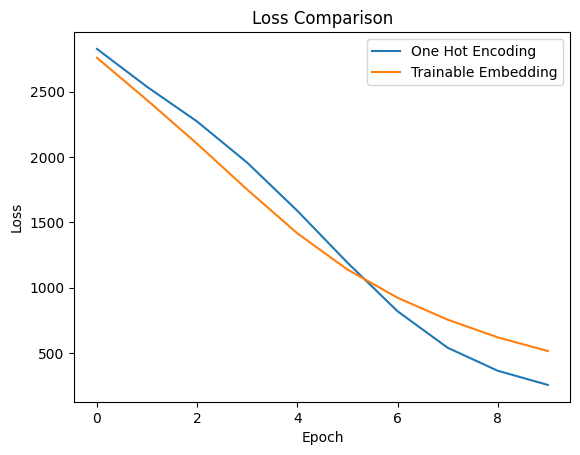

In [36]:
import matplotlib.pyplot as plt

plt.plot(losses_onehot, label="One Hot Encoding")
plt.plot(losses_embed, label="Trainable Embedding")
plt.legend()
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss Comparison")
plt.show()


Examples

In [37]:
print("----- ONE HOT MODEL -----")
print(generate(model_onehot, "the night"))
print(generate(model_onehot, "my heart"))
print(generate(model_onehot, "in the sky"))

print("\n----- EMBEDDING MODEL -----")
print(generate(model_embed, "the night"))
print(generate(model_embed, "my heart"))
print(generate(model_embed, "in the sky"))


----- ONE HOT MODEL -----
the night of waters ever the night and dark nothing all night i will never measured and look with you measured and
my heart and reach we 're tired my heart and i though now and takes the sun i seemed with less and
in the sky and with the house and i use in the whole and does the trail of their heads laugh that burial

----- EMBEDDING MODEL -----
the night 's quadrangular houses to die and i know what i knew who to me so we had receiv 'd at
my heart is crowded by and sit myself apart from the beef i will the sounds of the dusk i make the
in the sky or men in the air that keep and many the poet of the moon along the beach came to the
